Астафьева Ксения Ки22-08Б 032210274

# Задание 7. Применение сверточной нейронной сети для классификации изображений
### Индивидуальное задание:
1. Суперкласс для классификации: Aquatic mammals (Водные млекопитающие);
2. Архитектура базовой модели нейронной сети:
   - Вход;
   - 2D-свёртка, 64 ядра 3x3, ReLU;
   - Макс-пулинг, 2x2;
   - 2D-свёртка, 8 ядер 3x3, ReLU;
   - Макс-пулинг, 2x2;
   - Преобразование в одномерный вектор;
   - Полносвязный, 32 нейрона, ReLU;
   - Полносвязный, 64 нейрона, ReLU;
   - Выход, полносвязный.

In [12]:
# Номер варианта, совпадает с номером используемого суперкласса
my_class = 0

## Порядок работы:  
### 1. Подключение библиотек

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import sklearn as skl
import sklearn.metrics as sklm
import tensorflow as tf
from tensorflow import keras as tfk
import pickle

In [10]:
def seed_reset():
    seed = 42
    np.random.seed(seed)
    tf.random.set_seed(seed)

In [18]:
def unpickle(file):
    import pickle

    with open(file, "rb") as fo:
        dict = pickle.load(fo, encoding="latin1")
    return dict


# Загрузка обучающей выборки
train_data = unpickle("train")
x_train_f = train_data["data"].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
y_train_f = np.array(train_data["fine_labels"]).reshape(-1, 1)
y_train_c = np.array(train_data["coarse_labels"]).reshape(-1, 1)

# Загрузка тестовой выборки
test_data = unpickle("test")
x_valid_f = test_data["data"].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
y_valid_f = np.array(test_data["fine_labels"]).reshape(-1, 1)
y_valid_c = np.array(test_data["coarse_labels"]).reshape(-1, 1)

### 2. Загрузка датасета

#### 2.1 Загружаем датасет CIFAR-100.  

In [19]:
print("Размерность валидационной выборки:", x_valid_f.shape)
print("Размерность вектора меток классов (fine):", y_valid_f.shape)
print("Число уникальных меток классов (fine):", len(np.unique(y_train_f)))
print("Число уникальных меток суперклассов (coarse):", len(np.unique(y_train_c)))

Размерность валидационной выборки: (10000, 32, 32, 3)
Размерность вектора меток классов (fine): (10000, 1)
Число уникальных меток классов (fine): 100
Число уникальных меток суперклассов (coarse): 20


#### 2.2 Считываем текстовые метки классов и суперклассов

In [20]:
metadata_path = 'meta'
metadata = unpickle(metadata_path)
superclass_dict = dict(enumerate(metadata['coarse_label_names']))

print("Список названий суперклассов:")
for idx, name in superclass_dict.items():
    print(f"{idx}: {name}")

Список названий суперклассов:
0: aquatic_mammals
1: fish
2: flowers
3: food_containers
4: fruit_and_vegetables
5: household_electrical_devices
6: household_furniture
7: insects
8: large_carnivores
9: large_man-made_outdoor_things
10: large_natural_outdoor_scenes
11: large_omnivores_and_herbivores
12: medium_mammals
13: non-insect_invertebrates
14: people
15: reptiles
16: small_mammals
17: trees
18: vehicles_1
19: vehicles_2


In [21]:
classes = dict(enumerate(metadata['fine_label_names']))

print("Список названий классов:")
print(classes)

Список названий классов:
{0: 'apple', 1: 'aquarium_fish', 2: 'baby', 3: 'bear', 4: 'beaver', 5: 'bed', 6: 'bee', 7: 'beetle', 8: 'bicycle', 9: 'bottle', 10: 'bowl', 11: 'boy', 12: 'bridge', 13: 'bus', 14: 'butterfly', 15: 'camel', 16: 'can', 17: 'castle', 18: 'caterpillar', 19: 'cattle', 20: 'chair', 21: 'chimpanzee', 22: 'clock', 23: 'cloud', 24: 'cockroach', 25: 'couch', 26: 'crab', 27: 'crocodile', 28: 'cup', 29: 'dinosaur', 30: 'dolphin', 31: 'elephant', 32: 'flatfish', 33: 'forest', 34: 'fox', 35: 'girl', 36: 'hamster', 37: 'house', 38: 'kangaroo', 39: 'keyboard', 40: 'lamp', 41: 'lawn_mower', 42: 'leopard', 43: 'lion', 44: 'lizard', 45: 'lobster', 46: 'man', 47: 'maple_tree', 48: 'motorcycle', 49: 'mountain', 50: 'mouse', 51: 'mushroom', 52: 'oak_tree', 53: 'orange', 54: 'orchid', 55: 'otter', 56: 'palm_tree', 57: 'pear', 58: 'pickup_truck', 59: 'pine_tree', 60: 'plain', 61: 'plate', 62: 'poppy', 63: 'porcupine', 64: 'possum', 65: 'rabbit', 66: 'raccoon', 67: 'ray', 68: 'road', 6

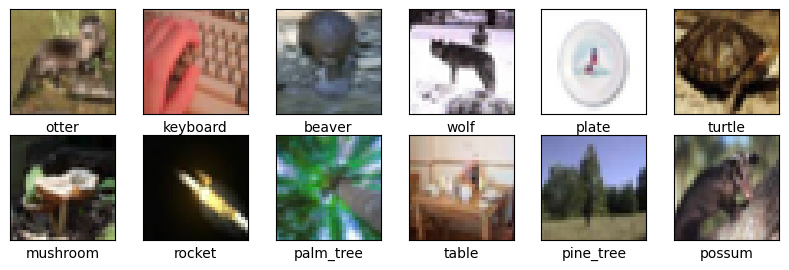

In [22]:
plt.figure(figsize=(10, 3))
for i in range(100, 112):
    plt.subplot(2, 6, i-100+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train_f[i])
    plt.xlabel(classes[y_train_f[i][0]])

### 3. Многоклассовая классификация изображений: подготовка данных для обучения и тестирования модели

#### 3.1. Выбираем из общей обучающей выборки суперкласс согласно варианту

In [26]:
def cclass_extract(xf, yf, yc, cclass):
    mask = yc.reshape(yc.shape[0]) == cclass
    return xf[mask], yf[mask]

def head12pic(x, y, classes):
    plt.figure(figsize=(10,3))
    for i in range(0,12):
        plt.subplot(2, 6, i+1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(x[i])
        plt.xlabel(classes[y[i][0]])
    plt.show()

In [32]:
x_train, y_train = cclass_extract(x_train_f, y_train_f, y_train_c, my_class)
print ("Размерность датафрейма обучающей выборки: ", x_train.shape)
print ("Размерность датафрейма меток обучающей выборки: ", y_train.shape)

NameError: name 'my_class' is not defined

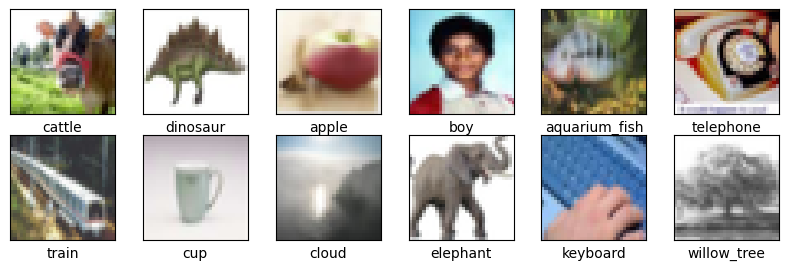

In [29]:
head12pic(x_train_f, y_train_f, classes)

#### 3.2. Выбираем из общей тестовой выборки суперкласс согласно варианту

In [31]:
x_valid_f, y_valid_f = cclass_extract(x_valid_f, y_valid_f, y_valid_c, my_class)
print ("Размерность датафрейма тестовой выборки: ", x_valid.shape)
print ("Размерность датафрейма меток тестовой выборки: ", y_valid.shape)

NameError: name 'my_class' is not defined

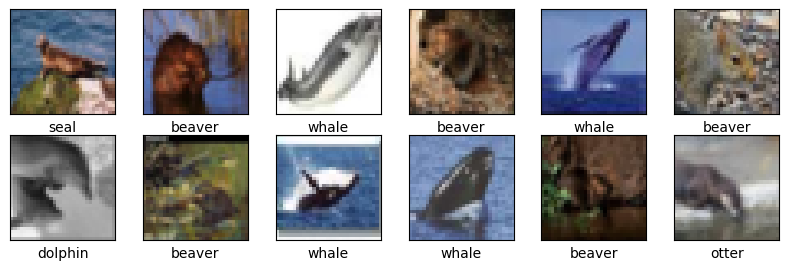

In [53]:
head12pic(x_valid, y_valid, classes)

#### 3.3. Нормализация данных и кодирование меток

In [54]:
def rank_transform(array):
    return np.unique(array, return_inverse=True)[1].reshape(array.shape)

In [55]:
x_train_n = np.divide(x_train, 255)
x_valid_n = np.divide(x_valid, 255)

In [56]:
y_train_n = tfk.utils.to_categorical(rank_transform(y_train))
y_valid_n = tfk.utils.to_categorical(rank_transform(y_valid))

### 4. Описание модели нейронной сети на базе класса Sequential

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 13, 13, 8)      │         4,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,093 (70.68 KB)

 Trainable params: 18,093 (70.68 KB)

 Non-trainable params: 0 (0.00 B)

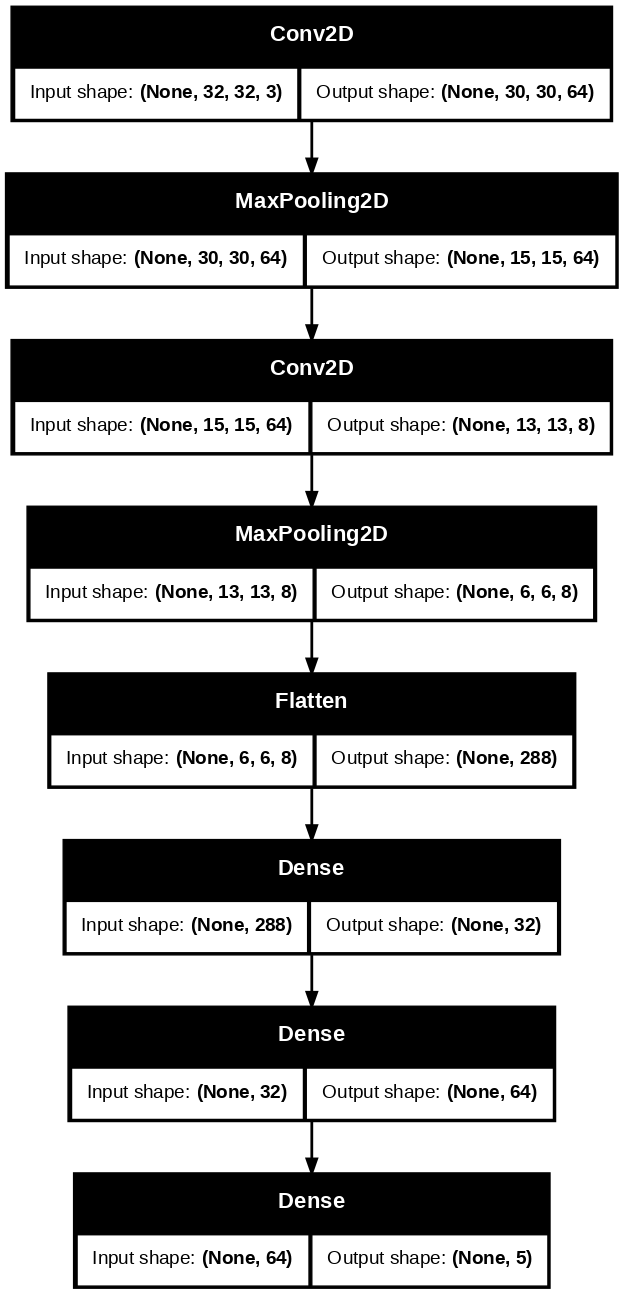

In [58]:
def create_model_aquatic(x, y):
    m = tfk.models.Sequential()
    m.add(tfk.Input(shape=x.shape[1:]))
    m.add(tfk.layers.Conv2D(64, (3, 3), activation='relu'))
    m.add(tfk.layers.MaxPooling2D(pool_size=(2, 2)))
    m.add(tfk.layers.Conv2D(8, (3, 3), activation='relu'))
    m.add(tfk.layers.MaxPooling2D(pool_size=(2, 2)))
    m.add(tfk.layers.Flatten())
    m.add(tfk.layers.Dense(32, activation='relu'))
    m.add(tfk.layers.Dense(64, activation='relu'))
    m.add(tfk.layers.Dense(y.shape[1], activation='softmax'))
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

modl = create_model_aquatic(x_train_n, y_train_n)
modl.summary()
tfk.utils.plot_model(modl, 'modl.png', show_shapes=True, dpi=100)

### 5. Обучение модели

In [59]:

class StupidDotter(tf.keras.callbacks.Callback):
    def __init__(self):
        super(StupidDotter, self).__init__()
        self.best_accuracy = 0
    def save_user_value(self, val):
        self.cur_custom = val
    def on_train_end(self, logs=None):
        # print('^', end='')
        print()
    def on_epoch_end(self, epoch, logs=None):
        if logs and logs['val_accuracy'] > self.best_accuracy:
            self.best_accuracy = logs['val_accuracy']
            print('!', end='')
        else:
            print('.', end='')

In [60]:
def check_model(model):
    print(f'Train accuracy: {model.evaluate(x_train_n, y_train_n, verbose=0)[1]}')
    print(f'Valid accuracy: {model.evaluate(x_valid_n, y_valid_n, verbose=0)[1]}')

In [63]:
reduce_lr = tfk.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy', factor=0.5, patience=5,
    min_lr=0.000001, verbose=0
)

save_best = tfk.callbacks.ModelCheckpoint(
    filepath="base_weights.keras", monitor="val_accuracy",
    save_best_only=True, mode="auto", verbose=0
)

early_stop = tfk.callbacks.EarlyStopping(
    monitor="val_accuracy", min_delta=0.0001, patience=8, verbose=0,
    mode='auto', baseline=None, restore_best_weights=True, start_from_epoch=0
)

dotter = StupidDotter()

seed_reset()

train_log_0 = modl.fit(
    x_train_n, y_train_n,
    batch_size=32, epochs=32,
    validation_data=(x_valid_n, y_valid_n),
    callbacks=[save_best, reduce_lr, early_stop, dotter],
    verbose=0
)

check_model(modl)

!!.!.!!.!.!!!........
Train accuracy: 0.6019999980926514
Valid accuracy: 0.5180000066757202


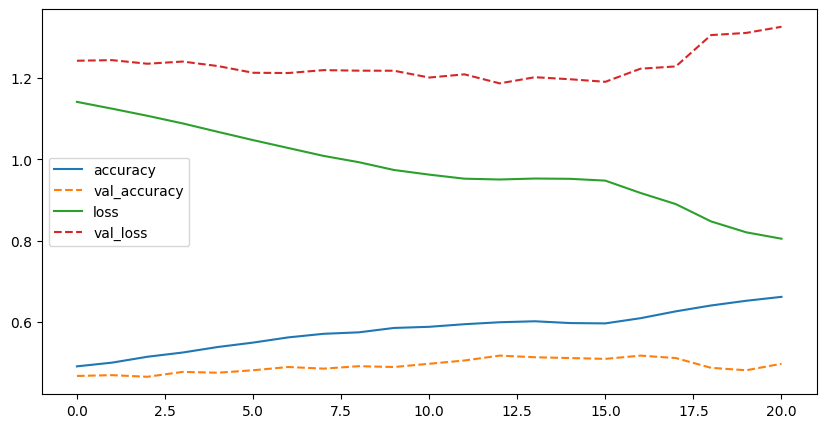

In [64]:
plt.subplots(figsize=(10,5))
plt.plot(train_log_0.history['accuracy'], label='accuracy')
plt.plot(train_log_0.history['val_accuracy'], label='val_accuracy', linestyle='--')
plt.plot(train_log_0.history['loss'], label='loss')
plt.plot(train_log_0.history['val_loss'], label='val_loss', linestyle='--')
plt.legend()
plt.show()

### 6. Оценка качества работы многоклассового классификатора  

#### 6.2. Построить матрицу ошибок

In [65]:
cm_labels = [classes[i] for i in np.unique(y_valid)]
def checker_m(test, pred):
    cm = sklm.confusion_matrix(test, pred)

    print('Accuracy  : {0:0.4f}'.format(sklm.accuracy_score(test, pred)))
    print('Precision : {0:0.4f}'.format(sklm.precision_score(test, pred, average='weighted')))
    print('Recall    : {0:0.4f}'.format(sklm.recall_score(test, pred, average='weighted')))

    global cm_labels
    plt.figure(figsize=(8,6))
    plt.title("Confusion Matrix")
    cm_matrix = pd.DataFrame(data=cm, index=cm_labels, columns=cm_labels)
    sns.heatmap(cm_matrix, annot=True, fmt='', cmap='coolwarm', norm=mcolors.LogNorm())
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
Accuracy  : 0.5180
Precision : 0.5269
Recall    : 0.5180


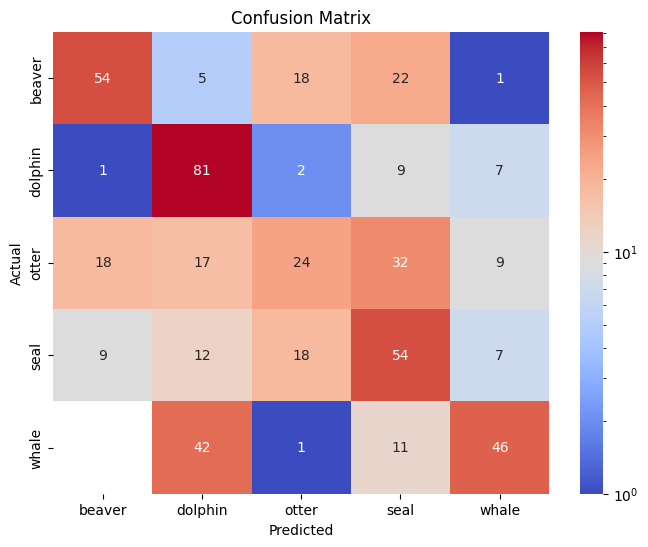

In [66]:
checker_m(
    np.argmax(y_valid_n, axis=1),
    np.argmax(modl.predict(x_valid_n), axis=1)
)

### 7. Оптимизация нейронной сети

## 7.1 Попытка 1

In [68]:
reduce_lr_1 = tfk.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy', factor=0.2, patience=4, min_lr=0.0001, verbose=0
)
early_stop_1 = tfk.callbacks.EarlyStopping(
    monitor="val_accuracy", min_delta=0.0001, patience=128, verbose=0, mode='auto',
    baseline=None, restore_best_weights=True, start_from_epoch=0
)
dotter_1 = StupidDotter()

modlo1 = create_model_0(x_train_n, y_train_n)

seed_reset()
train_log_1 = modlo1.fit(
    x_train_n, y_train_n,
    batch_size=64, epochs=64,
    validation_data=(x_valid_n, y_valid_n),
    callbacks=[reduce_lr_1, early_stop_1, dotter_1],
    verbose=0
)

check_model(modlo1)

!!.!!!!!!!..!!!!....!.....................!.!.!.!...............
Train accuracy: 0.9372000098228455
Valid accuracy: 0.5699999928474426


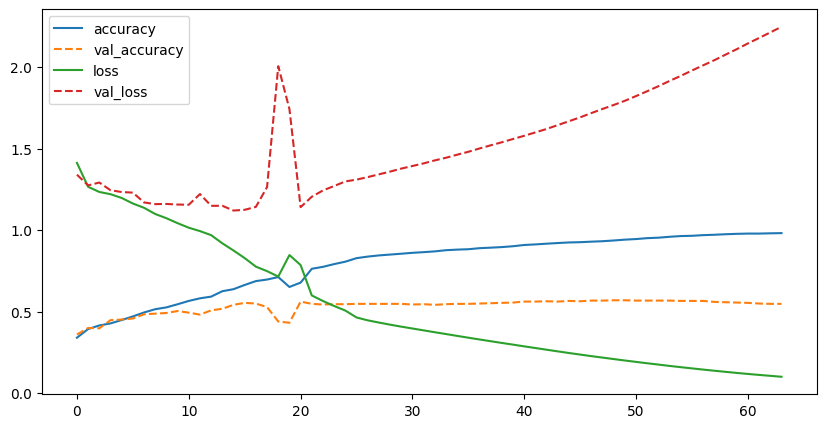

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Accuracy  : 0.5700
Precision : 0.5639
Recall    : 0.5700


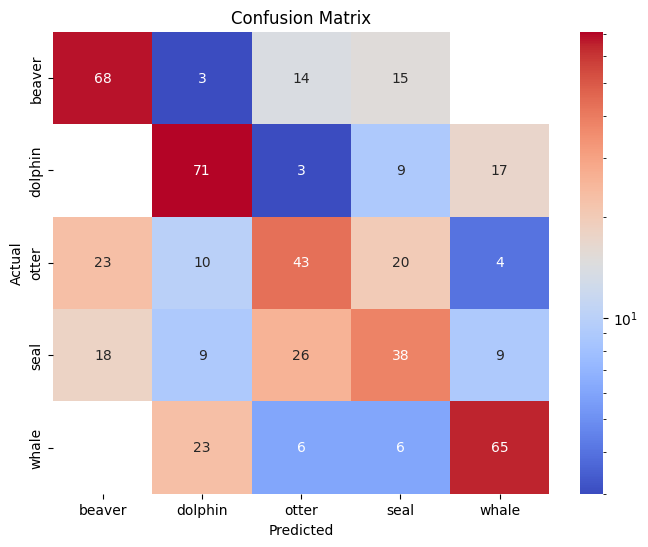

In [70]:
plt.subplots(figsize=(10,5))
plt.plot(train_log_1.history['accuracy'], label='accuracy')
plt.plot(train_log_1.history['val_accuracy'], label='val_accuracy', linestyle='--')
plt.plot(train_log_1.history['loss'], label='loss')
plt.plot(train_log_1.history['val_loss'], label='val_loss', linestyle='--')
plt.legend()
plt.show()
checker_m(
    np.argmax(y_valid_n, axis=1),
    np.argmax(modlo1.predict(x_valid_n), axis=1)
)

## 7.2 Попытка 2

Добавим в модель этапы забывания

In [71]:
def create_model_2(x, y):
    m = tfk.models.Sequential()
    m.add(tfk.Input(shape=x.shape[1:]))

    m.add(tfk.layers.Conv2D(16, (5,5), activation='relu'))
    m.add(tfk.layers.MaxPooling2D(pool_size=(2,2)))

    m.add(tfk.layers.Conv2D(32, (3,3), activation='relu'))
    m.add(tfk.layers.MaxPooling2D(pool_size=(2,2)))
    m.add(tfk.layers.Dropout(0.5))

    m.add(tfk.layers.Conv2D(64, (3,3), activation='relu'))
    m.add(tfk.layers.MaxPooling2D(pool_size=(2,2)))

    m.add(tfk.layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    m.add(tfk.layers.MaxPooling2D(pool_size=(2,2)))

    m.add(tfk.layers.Flatten())
    m.add(tfk.layers.Dense(128, activation='relu'))
    m.add(tfk.layers.Dropout(0.5))

    m.add(tfk.layers.Dense(64, activation='relu'))
    m.add(tfk.layers.Dense(y.shape[1], activation='softmax'))

    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

In [72]:
reduce_lr_2 = tfk.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy', factor=0.2, patience=4, min_lr=0.0001, verbose=0
)
early_stop_2 = tfk.callbacks.EarlyStopping(
    monitor="val_accuracy", min_delta=0.0001, patience=128, verbose=0, mode='auto',
    baseline=None, restore_best_weights=True, start_from_epoch=0
)
dotter_2 = StupidDotter()

modlo2 = create_model_2(x_train_n, y_train_n)

seed_reset()
train_log_2 = modlo2.fit(
    x_train_n, y_train_n,
    batch_size=64, epochs=128,
    validation_data=(x_valid_n, y_valid_n),
    callbacks=[reduce_lr_2, early_stop_2, dotter_2],
    verbose=0
)

check_model(modlo2)

!!...!....!.!.......!.......!....!.....!........!!....!!.......!...............................................!....!.......!...
Train accuracy: 0.6123999953269958
Valid accuracy: 0.527999997138977


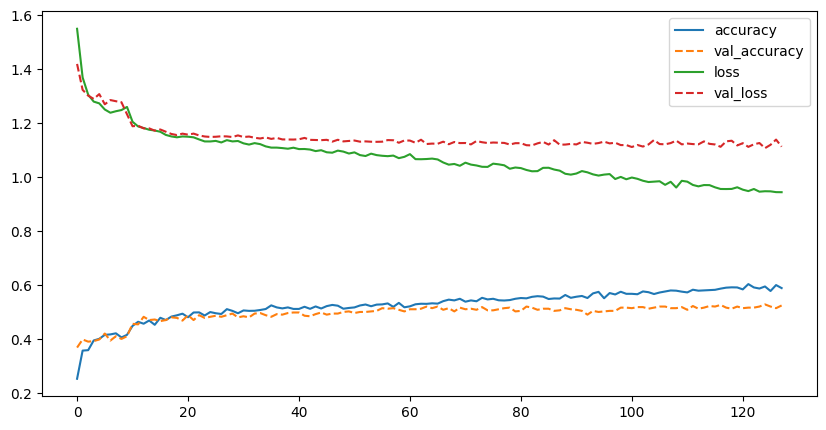

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Accuracy  : 0.5280
Precision : 0.5524
Recall    : 0.5280


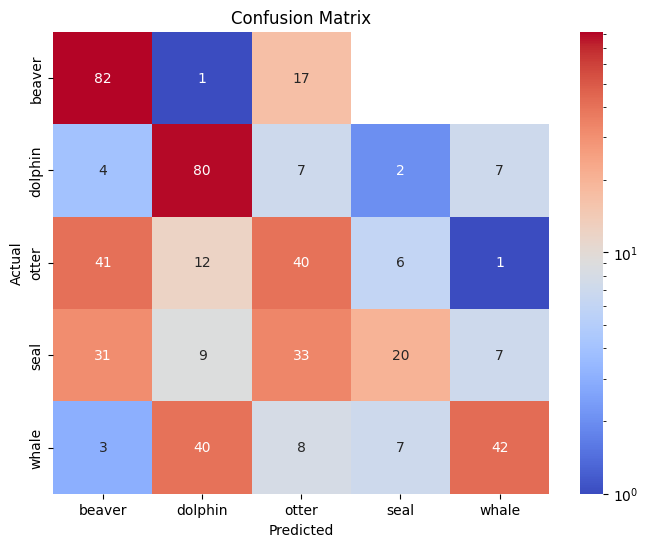

In [73]:
plt.subplots(figsize=(10,5))
plt.plot(train_log_2.history['accuracy'], label='accuracy')
plt.plot(train_log_2.history['val_accuracy'], label='val_accuracy', linestyle='--')
plt.plot(train_log_2.history['loss'], label='loss')
plt.plot(train_log_2.history['val_loss'], label='val_loss', linestyle='--')
plt.legend()
plt.show()
checker_m(
    np.argmax(y_valid_n, axis=1),
    np.argmax(modlo2.predict(x_valid_n), axis=1)
)

## 8. Сохранение оптимизированной модели в файл

In [78]:
modl.save('saved.keras')